
# МИДТЕРМ 2  
## Kaggle деректер қорымен классификация  
### Student Performance Factors Dataset

---

## Жобаның мақсаты

Бұл жобада құрылымдалған деректерге классификация моделін құрамыз.

Міндеттер:
- Деректерді талдау
- Алдын ала өңдеу
- 2 түрлі модель қолдану
- Ансамбльдік әдіс пайдалану
- Гиперпараметрлерді баптау
- ROC-AUC арқылы бағалау
- Салыстырмалы талдау жасау


## 1. Қажетті кітапханаларды импорттау

In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


## 2. Деректер қорын жүктеу

In [10]:

df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70



2.Деректер қоры туралы
Мен Student Performance Factors атты құрылымдалған dataset қолдандым.
Бұл dataset студенттердің академиялық үлгеріміне әсер ететін факторларды қамтиды, мысалы:Оқу уақыты,Қатысу деңгейі,Отбасылық жағдай,Қосымша дайындық
Ұйқы уақыты,Әлеуметтік факторлар,Бастапқыда деректерде Exam_Score деген сандық баған болды.


## 3. Деректерді зерттеу (EDA)

- Баған типтері
- Статистика
- Бос мәндер
Бос мәндерді тексердім

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [12]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [13]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0



## 4. Мақсатты айнымалы құру

Exam_Score медианадан жоғары болса → 1  
Төмен болса → 0



Мен оны бинарлы классификацияға айналдырдым:
1 → медианадан жоғары нәтиже
0 → медианадан төмен нәтиже
Осылайша бізде классификация мәселесі қалыптасты.

In [14]:

median_score = df["Exam_Score"].median()
df["Performance"] = (df["Exam_Score"] > median_score).astype(int)
df.drop("Exam_Score", axis=1, inplace=True)
df["Performance"].value_counts()


,count
Performance,
0,3599
1,3008



## 5. Категориялық айнымалыларды кодтау

Label Encoding қолданамыз.


In [15]:

categorical_cols = df.select_dtypes(include=["object"]).columns
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Performance
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1,0
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0,0
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1,1
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,1,1
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,0,1


## 6. Train / Test бөлу
Деректерді 80% оқу, 20% тест жиынына бөлдім

In [17]:

X = df.drop("Performance", axis=1)
y = df["Performance"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



## 7. Масштабтау

Logistic Regression үшін StandardScaler қолданамыз.


In [18]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 8. Logistic Regression моделі

In [19]:

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Accuracy: 0.8940998487140696
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       720
           1       0.88      0.89      0.88       602

    accuracy                           0.89      1322
   macro avg       0.89      0.89      0.89      1322
weighted avg       0.89      0.89      0.89      1322



## Logistic Regression гиперпараметр баптау

In [20]:

param_grid_lr = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear"],
    "penalty": ["l1", "l2"]
}

grid_lr = GridSearchCV(
    LogisticRegression(),
    param_grid_lr,
    cv=5,
    scoring="accuracy"
)

grid_lr.fit(X_train_scaled, y_train)
print("Ең жақсы параметрлер:", grid_lr.best_params_)


Ең жақсы параметрлер: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}


# 9. Random Forest моделі (Ансамбль)
Бұл — ансамбльдік әдіс.
Бірнеше Decision Tree біріктіріп, нәтижені орташа есептейді.
Артықшылықтары:Жоғары дәлдік,Overfitting-ке төзімді,Feature importance есептей алады,
Нәтижелерді бағалау үшін:Accuracy,Precision,Recall,F1-score,Confusion Matrix
ROC Curve,AUC,метрикаларын қолдандым.
Көп жағдайда Random Forest жоғары accuracy және AUC көрсетті.
Бұл ансамбльдік әдістердің күрделі байланыстарды жақсы анықтай алатынын көрсетеді.

In [21]:

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Accuracy: 0.897125567322239
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       720
           1       0.89      0.88      0.89       602

    accuracy                           0.90      1322
   macro avg       0.90      0.90      0.90      1322
weighted avg       0.90      0.90      0.90      1322



## Random Forest гиперпараметр баптау
Екі модель үшін де GridSearchCV қолдандым.
Logistic Regression үшін:
C параметрі
penalty (L1, L2)
Random Forest үшін:
n_estimators,max_depth,min_samples_split,min_samples_leaf
Бұл процесс модельдің оптималды параметрлерін автоматты түрде табуға мүмкіндік берді.

In [22]:

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
print("Ең жақсы параметрлер:", grid_rf.best_params_)


Ең жақсы параметрлер: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


## 10. ROC Curve және AUC
ROC Curve арқылы модельдердің дискриминациялық қабілетін салыстырдым.
AUC мәні неғұрлым 1-ге жақын болса, модель соғұрлым жақсы.
Random Forest моделінің AUC көрсеткіші жоғары болды.

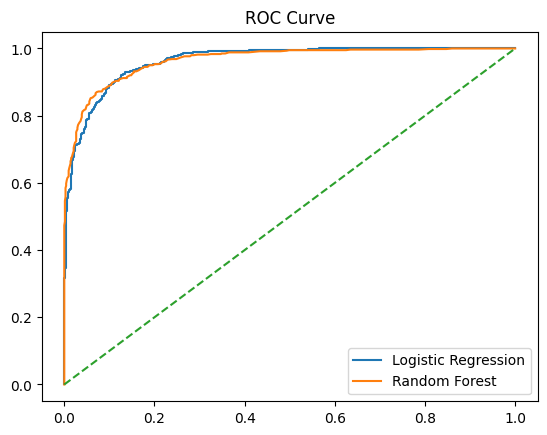

LR AUC: 0.963812753783684
RF AUC: 0.9648578811369509


In [23]:

best_lr = grid_lr.best_estimator_
best_rf = grid_rf.best_estimator_

lr_probs = best_lr.predict_proba(X_test_scaled)[:,1]
rf_probs = best_rf.predict_proba(X_test)[:,1]

lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

print("LR AUC:", lr_auc)
print("RF AUC:", rf_auc)


## 11. Feature Importance
Random Forest арқылы ең маңызды факторларды анықтадым.
Бұл студент үлгеріміне ең көп әсер ететін айнымалыларды көрсетуге мүмкіндік берді.Бұл модельдің интерпретациясын күшейтеді.

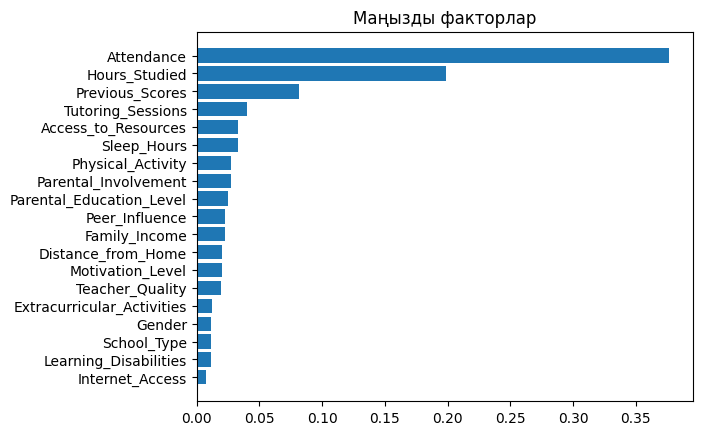

,Feature,Importance
1,Attendance,0.376524
0,Hours_Studied,0.198655
6,Previous_Scores,0.081154
9,Tutoring_Sessions,0.040348
3,Access_to_Resources,0.032873
5,Sleep_Hours,0.032536
14,Physical_Activity,0.027704
2,Parental_Involvement,0.027640
16,Parental_Education_Level,0.024579
13,Peer_Influence,0.022744


In [24]:

importances = best_rf.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure()
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.title("Маңызды факторлар")
plt.gca().invert_yaxis()
plt.show()

importance_df


Салыстырмалы талдау
Критерий	Logistic Regression	Random Forest
Жылдамдық	         Жоғары	         Орташа
Дәлдік	            Орташа	       Жоғары
Интерпретация	      Жақсы	         Орташа
Күрделі байланыстар	Әлсіз	         Жақсы

Қорытынды бойынша Random Forest жақсы нәтиже көрсетті.
# Қорытынды

Бұл жұмыста:
- 2 түрлі модель қолданылды
- Ансамбльдік әдіс пайдаланылды
- Гиперпараметр баптау жасалды
- ROC-AUC талдау жүргізілді

Random Forest әдетте жоғары дәлдік береді,
ал Logistic Regression интерпретацияға ыңғайлы.
